# 🚌 Project 1: Traffic Patterns🚉
##### Author: Mike Ee, [mikeee.co](https://mikeee.co)

<style>
.fig-caption {
    background-color: #f4f4f4;
    border-left: 4px solid #1e1e1e;
    padding: 8px 12px;
    margin-top: -4px;
    font-size: 0.9em;
    font-style: italic;
}
.section-header {
    border-bottom: 2px solid #ccc;
    padding-bottom: 4px;
    margin-top: 30px;
}
.section-callout {
    background-color: #fff8e1;
    border: 1px solid #ffca28;
    border-radius: 4px;
    padding: 10px 14px;
    margin: 10px 0;
}
</style>

Research Question (RQ): 
> <b> How does bus passenger load vary on weekdays </b> in the north eastern corridor of Singapore, specifically at the Kovan-Serangoon-Woodleigh region, and what does the <b>concentration of passenger load</b> suggest about <i>bus-rail integration</i> stated in LTMP 2040?

<div class="section-header">

## Table of Contents

</div>

1. [Background](#background)
2. [Load data](#data)
3. [Methodology](#methodology)
4. [Exploratory Data Analysis](#eda)
5. [Conclusion](#conclusion)
6. [References & Acknowledgements](#ref)

<a id="background"></a>
## 1. Background

<u>Policy context</u>
As part of the Singapore Land Transport Masterplan (LTMP) 2040's Walk-Cycle-Ride goals, there is a strong desire to strive for greater multi-modal journeys (i.e. bus-train transfers).

<u>Inquiry focus</u>
I was interested to examine how bus passenger load varies in the north eastern corridor of Singapore due to news reports of heavy congestion in this region. By looking at datasets available on the Land Transport Authority (LTA) datamall server, I was also curious to determine if there was any implications for bus and rail services for affected commuters.

<a id="data"></a>
## 2. Load data

### 2.1 Retrieve Bus Stop dataset from Singapore LTA Datamall

In [1]:
# Setup
import requests
import json
import pandas as pd
!pip install python-dotenv

from dotenv import load_dotenv
import os

load_dotenv()

account_key = os.environ["LTA_ACCOUNT_KEY"]
onemap_email = os.environ["ONEMAP_EMAIL"]
onemap_password = os.environ["ONEMAP_PASSWORD"]

headers = {"AccountKey": account_key, "accept": "application/json"}
response = requests.get("https://datamall2.mytransport.sg/ltaodataservice/BusStops", headers=headers)

# Check Status Code Query (200 = OK)
print(f"Query Status Code: {response.status_code}")

# Check number of records being returned in call
print(f"Number of records: {len(response.json()['value'])}")

# Print results in more readable JSON format
#print(json.dumps(response.json(), indent=2))

Query Status Code: 200
Number of records: 500


### 2.2 Load all Bus Stop data via pagination

In [2]:
# Coding pagination to ensure all entries in server dataset are called
# Varible to store all entries (think of adding garlic to an empty bowl)
all_records = []  
skip = 0

while True:                                      # $skip suggested from API documentation
    url = f"{"https://datamall2.mytransport.sg/ltaodataservice/BusStops"}?$skip={skip}"             
    response = requests.get(url, headers=headers)
    batch = response.json().get("value", [])
    
    if len(batch) == 0:                          # stop once garlic is gone
        break
    
    all_records.extend(batch)                    # add garlic clove to bowl
    
    if len(batch) < 500:                         # last clove - stop
        break
    
    skip += 500                                  # move to next clove

df = pd.DataFrame(all_records)                   # storing all records as a new df

In [3]:
# Examine bus stop records
df

,BusStopCode,RoadName,Description,Latitude,Longitude
0,01012,Victoria St,Hotel Grand Pacific,1.296848,103.852536
1,01013,Victoria St,St. Joseph's Ch,1.297710,103.853225
2,01019,Victoria St,Bras Basah Cplx,1.296990,103.853022
3,01029,Nth Bridge Rd,Opp Natl Lib,1.296673,103.854414
4,01039,Nth Bridge Rd,Bugis Cube,1.298208,103.855491
...,...,...,...,...,...
5200,99139,Changi Village Rd,Blk 5,1.388195,103.987234
5201,99161,Nicoll Dr,Aft Changi Beach CP 3,1.390303,103.992975
5202,99171,Nicoll Dr,Changi Beach CP 2,1.391161,103.990992
5203,99181,Telok Paku Rd,Bef S'pore Aviation Ac,1.387793,103.988393


#### 2.2.1 Observations 🤔
* Made a total of 11 calls for Bus Stop dataset, 10 full batches of 500

### 2.3 Retrieve Passenger Volume by Bus Stop dataset via API call

In [4]:
# Coding API call for Passenger Volume by Bus Stop CSV download link
headers = {"AccountKey": account_key, "accept": "application/json"}
response = requests.get("https://datamall2.mytransport.sg/ltaodataservice/PV/Bus", headers=headers)

# Check Status Code Query (200 = OK)
print(f"Query Status Code: {response.status_code}")

# Check number of records being returned in call
print(f"Number of records: {len(response.json()['value'])}")

Query Status Code: 200
Number of records: 1


In [5]:
# Importing the io module, a Python lib that provides core tools for working with streams - objs tt rep 
# data sources or destinations (e.g. files, in-memory buffers, or network connections.ta sources or destinations, 
# such as files, in-memory buffers, or network connections.
import io
# zipfile module necy for extracting python-ready data from zipped files
import zipfile 

# Extract temp dl URL from JSON metadata
api_data = response.json().get("value", [])

if api_data:
# Retrieve URL from the 'Link' key of the first record 
#(in this case there is only 1 record as indicated by API docu)
    actual_download_url = api_data[0].get("Link")
    print(f"Download Link Found: {actual_download_url.split('?')[0]}")  # omit pre-signed token

# Create a header mimicking a standard web browser for script to appear human
# so that it can gain entry into Amazon S3 cloud server to access dataset
# Without this line, returns 403 Forbidden
    download_headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# Request dl of zip file content with the headers attached
    file_response = requests.get(actual_download_url, headers=download_headers)
    
    if file_response.status_code == 200:
# Read the zip file directly from memory and extract it
# io.BytesIO treats downloaded bytes like a file without writing to local
        with zipfile.ZipFile(io.BytesIO(file_response.content)) as z:
# Get the name of the CSV file inside the zip
            csv_filename = z.namelist()[0]
            print(f"Extracting: {csv_filename}")

# Loading data into second dataframe
            df2 = pd.read_csv(z.open(csv_filename))

# Local export
        df2.to_csv("PVbus.csv", index=False, encoding="utf-8")
        print("Success! 'PVbus.csv' has been saved.")
    else:
        print(
            f"Failed to download the zip file. Status code: {file_response.status_code}"
        )
else:
    print("No download links found in the API response.")

Download Link Found: https://ltafarecard.s3.ap-southeast-1.amazonaws.com/202605/transport_node_bus_202605.zip [pre-signed query string removed]
Extracting: transport_node_bus_202605.csv


Success! 'PVbus.csv' has been saved.


### 2.4 Inner left join of two datasets via BusStopCode and PT_Code

In [6]:
# To join 'BusStopCode' ~ need to convert to int
df.dtypes 

BusStopCode     object
RoadName        object
Description     object
Latitude       float64
Longitude      float64
dtype: object

In [7]:
# Convert the 'points' column from object to integer
df['BusStopCode'] = df['BusStopCode'].astype(int)
print(df.dtypes)

BusStopCode      int64
RoadName        object
Description     object
Latitude       float64
Longitude      float64
dtype: object


In [8]:
# with 'PT_CODE'
df2.dtypes

YEAR_MONTH               object
DAY_TYPE                 object
TIME_PER_HOUR           float64
PT_TYPE                  object
PT_CODE                   int64
TOTAL_TAP_IN_VOLUME       int64
TOTAL_TAP_OUT_VOLUME      int64
dtype: object

In [9]:
# Set variable for join function
merged = df.merge(df2, left_on="BusStopCode", right_on="PT_CODE", how="left")
print(merged.shape)

(203062, 12)


In [10]:
print(merged.isna().sum())

BusStopCode              0
RoadName                 0
Description              0
Latitude                 0
Longitude                0
YEAR_MONTH               7
DAY_TYPE                 7
TIME_PER_HOUR           18
PT_TYPE                  7
PT_CODE                  7
TOTAL_TAP_IN_VOLUME      7
TOTAL_TAP_OUT_VOLUME     7
dtype: int64


### 2.5 Examining null values in dataset

In [11]:
# Filter only null values under PT_CODE 
nan_rows = merged[merged['PT_CODE'].isna()]
nan_rows.head(10)

,BusStopCode,RoadName,Description,Latitude,Longitude,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME
56589,27601,Bulim Walk,Bef Jurong West St 22,1.354372,103.704718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56590,27609,Bulim Walk,Aft Jurong West St 25,1.354514,103.704522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56591,27611,Bulim Dr,Bef Bulim Walk,1.357217,103.703971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56592,27619,Bulim Dr,Aft Bulim Walk,1.356928,103.703352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63012,31009,Old Choa Chu Kang Rd,Choa Chu Kang Rd End,1.371744,103.684266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83803,44821,Senja Link,Blk 651,1.386376,103.763384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146591,65791,Punggol East,Waterway Pr Sch,1.398805,103.919084,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Including TIME_PER_HOUR
# | gives union, & gives intercept
nan_rows = merged[merged['TIME_PER_HOUR'].isna() | merged['PT_CODE'].isna()]

# Verify max rows with NaN values
print(nan_rows.shape)

# What can we see?
nan_rows.head(18) 

(18, 12)


,BusStopCode,RoadName,Description,Latitude,Longitude,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME
9014,10009,Bt Merah Ctrl,Bt Merah Int,1.282102,103.817225,2026-05,WEEKENDS/HOLIDAY,NaN,BUS,10009.0,0.0,2.0
25446,17009,Clementi Ave 3,Clementi Int,1.314916,103.764122,2026-05,WEEKENDS/HOLIDAY,NaN,BUS,17009.0,0.0,1.0
56589,27601,Bulim Walk,Bef Jurong West St 22,1.354372,103.704718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56590,27609,Bulim Walk,Aft Jurong West St 25,1.354514,103.704522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56591,27611,Bulim Dr,Bef Bulim Walk,1.357217,103.703971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56592,27619,Bulim Dr,Aft Bulim Walk,1.356928,103.703352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63012,31009,Old Choa Chu Kang Rd,Choa Chu Kang Rd End,1.371744,103.684266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71491,43009,Bt Batok Ctrl,Bt Batok Int,1.349994,103.751062,2026-05,WEEKENDS/HOLIDAY,NaN,BUS,43009.0,0.0,1.0
77936,44009,Choa Chu Kang Loop,Choa Chu Kang Int,1.385869,103.745789,2026-05,WEEKDAY,NaN,BUS,44009.0,0.0,1.0
83803,44821,Senja Link,Blk 651,1.386376,103.763384,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.5.1 Observations 🤔

* For purposes of this analysis, we can drop 15 rows because they are found outside of geo corridor of interest
* Keep only: 
    * 64009 (Hougang Ctrl) -> drop because it collects info on weekend/holiday (we are only interested in weekday congestion), 
    * 65791 (Punggol East) -> drop because NaN values exist across 7 columns, so this entry is likely an extreme outlier of no value 
    * 66009 (S'goon Ave 2) -> drop, reason same as 64009
* Confirmed that there are 24 hours p/day being recorded in extracted PV dataset 

#### 2.5.2 🥡Take-away🥢

* To sharpen RQ focus:
    * To what extent does congestion happen <b>on weekdays</b> at the North East corridor of Singapore, and what implications could this have for multi-modal journeys?

In [13]:
# Drop true non-matches (i.e. no PV data at all)
merged_clean = merged[merged['PT_CODE'].notna()]

# Keep only weekday rows (project focus = congestion)
merged_clean = merged_clean[merged_clean['DAY_TYPE'] == 'WEEKDAY']

print(merged_clean.shape)

(101757, 12)

In [14]:
# Selecting TIME_PER_HOUR column and returns all distinct values,
# ranging from 0 to 23 = 24 hours p/day (+ NaN) being recorded in PV dataset
sorted(merged_clean['TIME_PER_HOUR'].unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(22.0),
 np.float64(23.0),
 np.float64(nan)]

<a id="methodology"></a>
## 3. Methodology

I chose to narrow my data analysis to weekday travel information specific to Kovan-Woodleigh-Serangoon.

### 3.1 Establishing North East Geographical Corridor for analysis

In [15]:
# Retrieve access token (expires 23 Jun 26)
auth_url = "https://www.onemap.gov.sg/api/auth/post/getToken"
payload = {"email": onemap_email, "password": onemap_password}

auth_response = requests.post(auth_url, json=payload)
token = auth_response.json()["access_token"]

In [16]:
headers = {"Authorization": token}

stations = ["kovan mrt", "serangoon mrt", "woodleigh mrt"]
station_coords = {}

for station in stations:
    url = f"https://www.onemap.gov.sg/api/common/elastic/search?searchVal={station}&returnGeom=Y&getAddrDetails=N"
    response = requests.get(url, headers=headers)
    results = response.json()["results"]
    
    station_coords[station] = (results[0]["LATITUDE"], results[0]["LONGITUDE"])

print(station_coords)

{'kovan mrt': ('1.35990191952976', '103.884494725197'), 'serangoon mrt': ('1.3510482896351', '103.871070417199'), 'woodleigh mrt': ('1.33982824592182', '103.87096088798')}


<table>
<tr>
    
<td style="vertical-align: top; width: 30%; fontsize=14;">

* Retrieved bounding box coordinates (i.e. minimum and maximum latitute and longitude values) via OneMap
* Use coordinates to form rectilinear boundary Pandas (see subsequent code blocks)

</td>

<td style="width: 70%;">
    
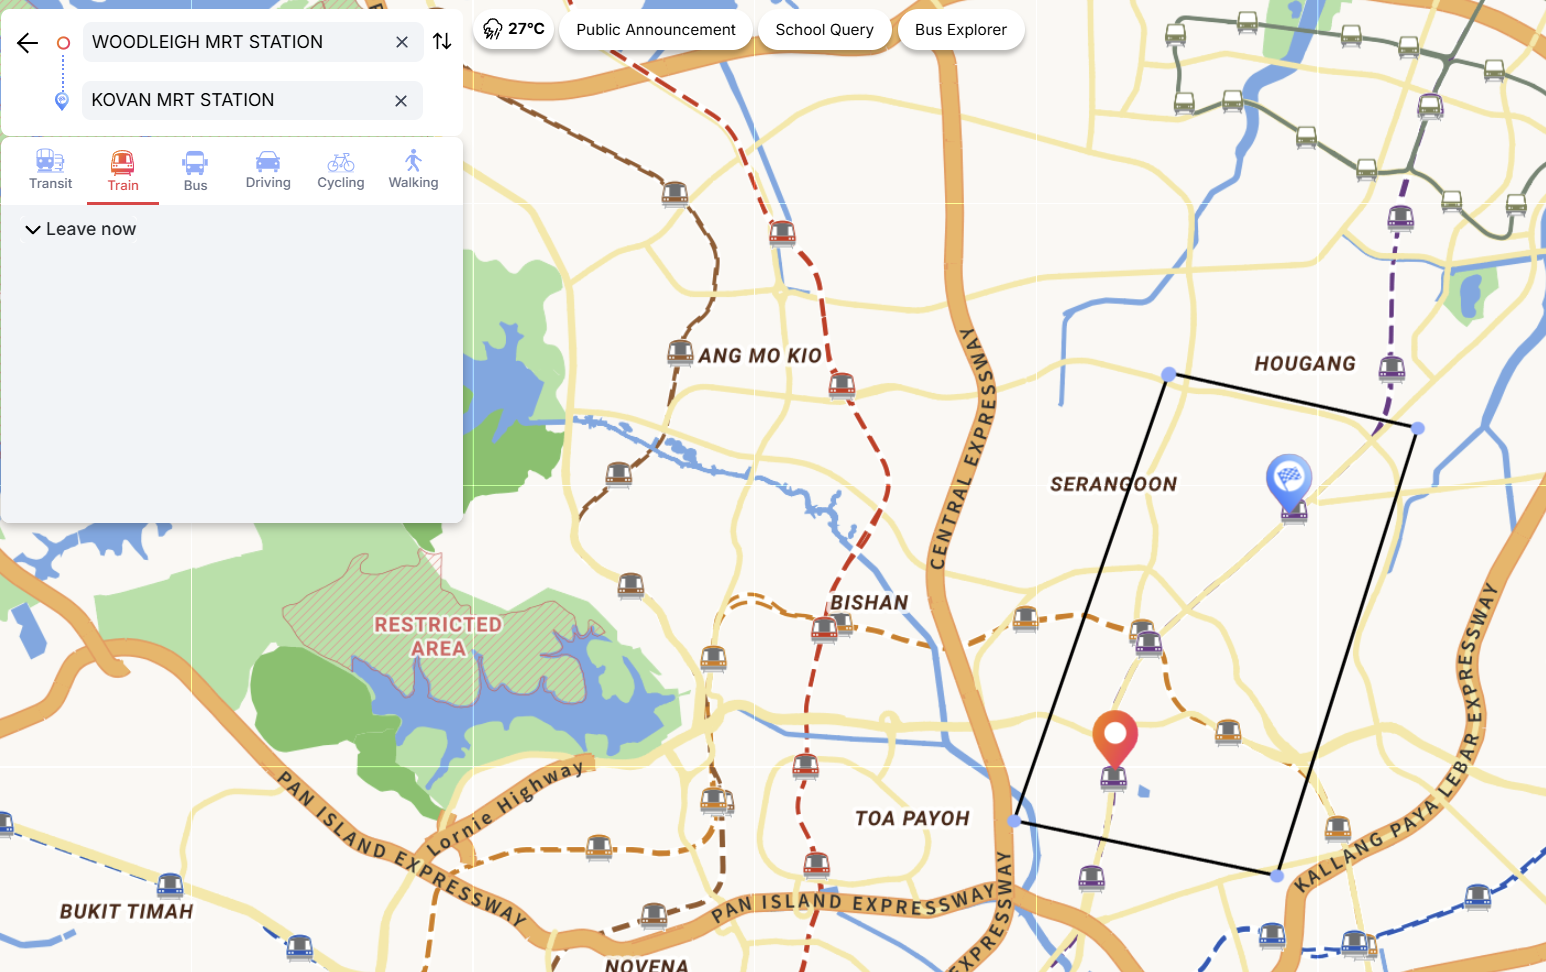

</td>
</tr>
</table>
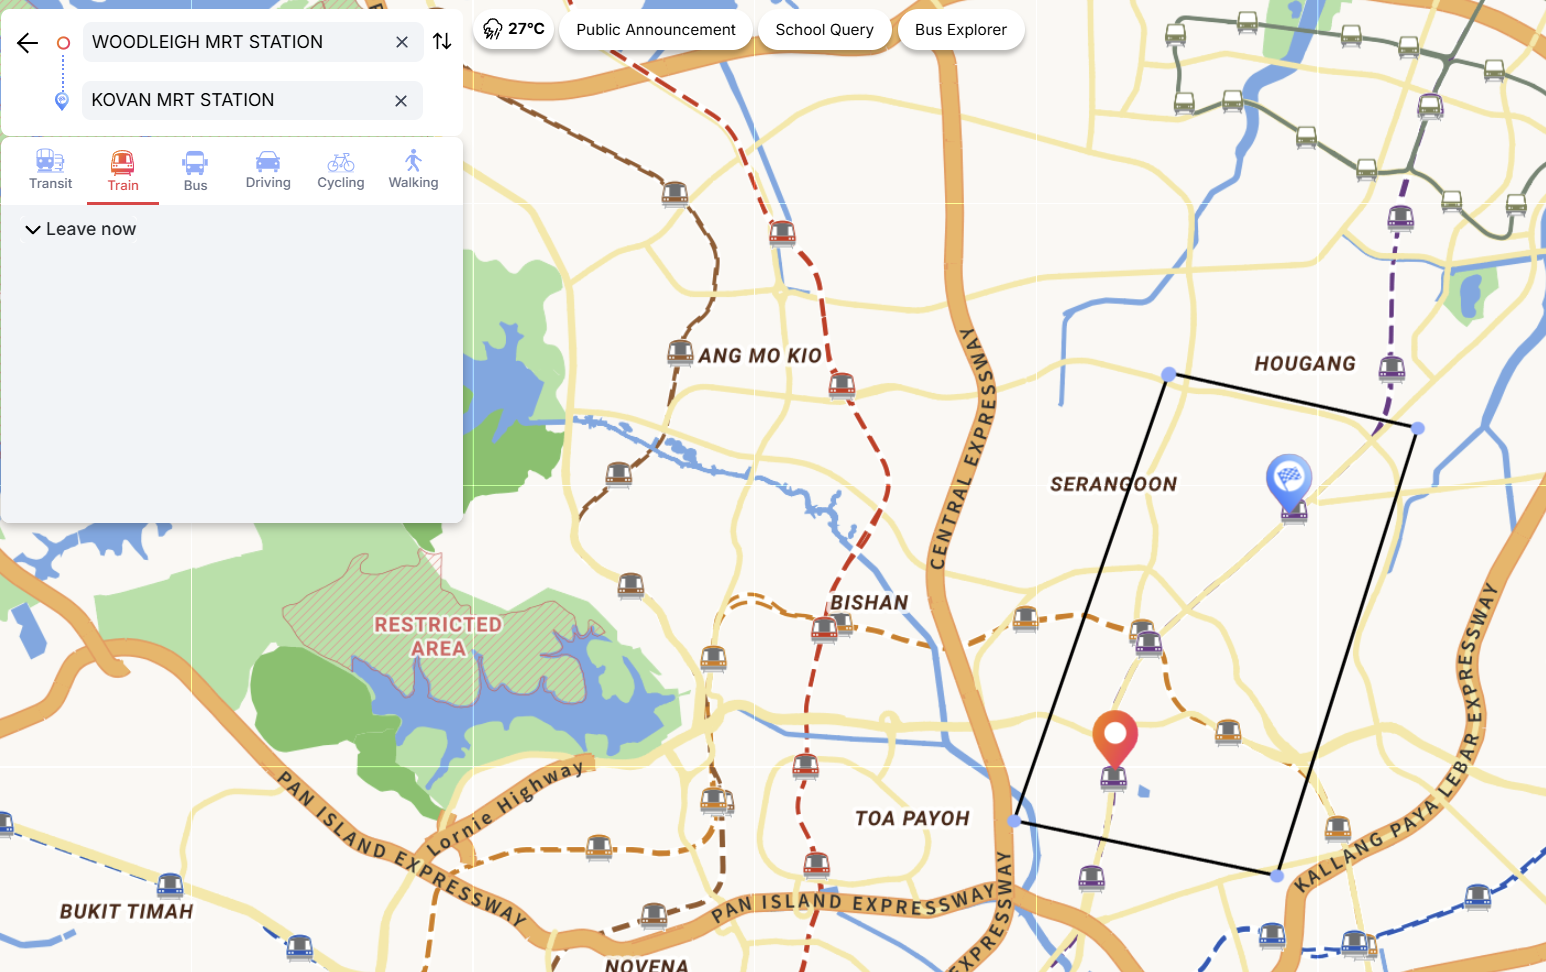

In [17]:
# Checking dtype in station_coords
for station, coords in station_coords.items():
    print(station, type(coords[0]), type(coords[1]))

kovan mrt <class 'str'> <class 'str'>
serangoon mrt <class 'str'> <class 'str'>
woodleigh mrt <class 'str'> <class 'str'>


In [18]:
lats = [float(coords[0]) for coords in station_coords.values()]
longs = [float(coords[1]) for coords in station_coords.values()]

In [19]:
lats # verify all values are now floats

[1.35990191952976, 1.3510482896351, 1.33982824592182]

In [20]:
longs # verify all values are now floats

[103.884494725197, 103.871070417199, 103.87096088798]

#### 3.1.1 🥡Take-away🥢
Kept engineering simple by drawing rectilinear bounding box around selected corridor for data analysis. 

Note: <code>station_coords</code> is a dictionary with 3 key-value pairs, 1 for each station.

### 3.2 Geographic filter

In [21]:
# Calculate min and max
min_lat = min(lats)
max_lat = max(lats)
min_long = min(longs)
max_long = max(longs)

print(f"Min Latitude: {min_lat}")
print(f"Max Latitude: {max_lat}")
print(f"Min Longitude: {min_long}")
print(f"Max Longitude: {max_long}")

Min Latitude: 1.33982824592182
Max Latitude: 1.35990191952976
Min Longitude: 103.87096088798
Max Longitude: 103.884494725197


In [22]:
# finally... the geo-filter we've been waiting for
in_corridor = (
    (merged_clean['Latitude'] >= min_lat) &
    (merged_clean['Latitude'] <= max_lat) &
    (merged_clean['Longitude'] >= min_long) &
    (merged_clean['Longitude'] <= max_long) 
)

# the final filtered corridor as a separate copy - yaY
corridor_df = merged_clean[in_corridor].copy()

# verify final rows we're working with 👀😋
print(corridor_df.shape)

(1278, 12)


#### 3.2.1 🥡Take-away🥢

* <code>in_corridor</code> determines which coordinates in `merged_clean` satisfy earlier filtering logic
* <code>merged_clean</code> in <code>corridor_df</code> function as a mask, similar to the earlier null values filter

### 3.3 Pre-EDA checks

In [23]:
# random check to ensure road names l00k correct based on domain knowledge 
corridor_df[['RoadName', 'Description', 'Latitude', 'Longitude']].drop_duplicates().head(15)

,RoadName,Description,Latitude,Longitude
132044,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969
132404,Bidadari Pk Dr,Opp Blk 212,1.341770,103.875484
132441,Bidadari Pk Dr,Blk 212,1.341638,103.874179
132561,Upp Paya Lebar Rd,Aft Bartley Rd,1.342135,103.883451
132600,Upp Paya Lebar Rd,Aft Rochdale Rd,1.342157,103.884053
132635,Upp Paya Lebar Rd,Wisma AUPE,1.343689,103.882507
132676,Upp Paya Lebar Rd,Paya Lebar Gdns,1.344113,103.882735
132715,Upp Paya Lebar Rd,Bef How Sun Rd,1.345210,103.881710
132757,Upp Paya Lebar Rd,Raya Gdn,1.346768,103.880912
132799,Upp Paya Lebar Rd,Opp Bethany Presby Ch,1.348383,103.880185


In [24]:
# Study statistical summary to btr understand spread
corridor_df.groupby('BusStopCode')['TIME_PER_HOUR'].nunique().describe()

count    63.000000
mean     20.285714
std       0.771019
min      18.000000
25%      20.000000
50%      20.000000
75%      21.000000
max      21.000000
Name: TIME_PER_HOUR, dtype: float64

#### 3.3.1 Observations 🤔

* 63 unique buses suggests that there are about 20.285 rows per bus stop on average.
* Minimum of 18 service hours with a max of 21 hours. This differs from earlier basis of 24 hours of recorded service hours per day.

In [25]:
# Checking unique hours found in TIME_PER_HOUR column
sorted(corridor_df['TIME_PER_HOUR'].unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(22.0),
 np.float64(23.0)]

#### 3.3.2 Observations 🤔

* Hours `2 – 4am` are absent across the corridor, consistent with most regular bus services terminating by `midnight – 1am`, with only select Night Rider services operating in the deep overnight period (not captured here).
* Can now expect that recorded, filtered data will have `18 - 21 service hour` range for buses.

In [26]:
corridor_df.groupby('BusStopCode')['TOTAL_TAP_IN_VOLUME'].sum().sort_values(ascending=False).head(10)

BusStopCode
66351    217652.0
66009    206179.0
66359    128172.0
62131     68923.0
66371     44516.0
66051     41415.0
62139     39352.0
66381     35691.0
62059     32562.0
62221     26921.0
Name: TOTAL_TAP_IN_VOLUME, dtype: float64

In [27]:
corridor_df.head(10)

,BusStopCode,RoadName,Description,Latitude,Longitude,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME
132044,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,22.0,BUS,61049.0,156.0,294.0
132045,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,15.0,BUS,61049.0,346.0,615.0
132046,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,6.0,BUS,61049.0,977.0,331.0
132047,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,5.0,BUS,61049.0,223.0,86.0
132050,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,23.0,BUS,61049.0,107.0,127.0
132052,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,7.0,BUS,61049.0,1675.0,708.0
132057,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,9.0,BUS,61049.0,987.0,471.0
132059,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,0.0,BUS,61049.0,29.0,32.0
132060,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,10.0,BUS,61049.0,557.0,255.0
132061,61049,Upp S'goon Rd,Aft Bartley Rd,1.341963,103.870969,2026-05,WEEKDAY,18.0,BUS,61049.0,690.0,1103.0


<a id="eda"></a>
## 4. Exploratory Data Analysis

This project's EDA engages with data visualisation of traffic congestion via plots and a heatmap.

### 4.1 Plotting high-density bus stops
* Sum of (tap-in + tap-out) across all hours, grouped by bus stops = total passenger volume

In [28]:
corridor_df['total_volume'] = corridor_df['TOTAL_TAP_IN_VOLUME'] + corridor_df['TOTAL_TAP_OUT_VOLUME']

stop_volume = (
    corridor_df
    .groupby(['BusStopCode', 'Description'], as_index=False)['total_volume']
    .sum()
    .sort_values('total_volume', ascending=False)
)


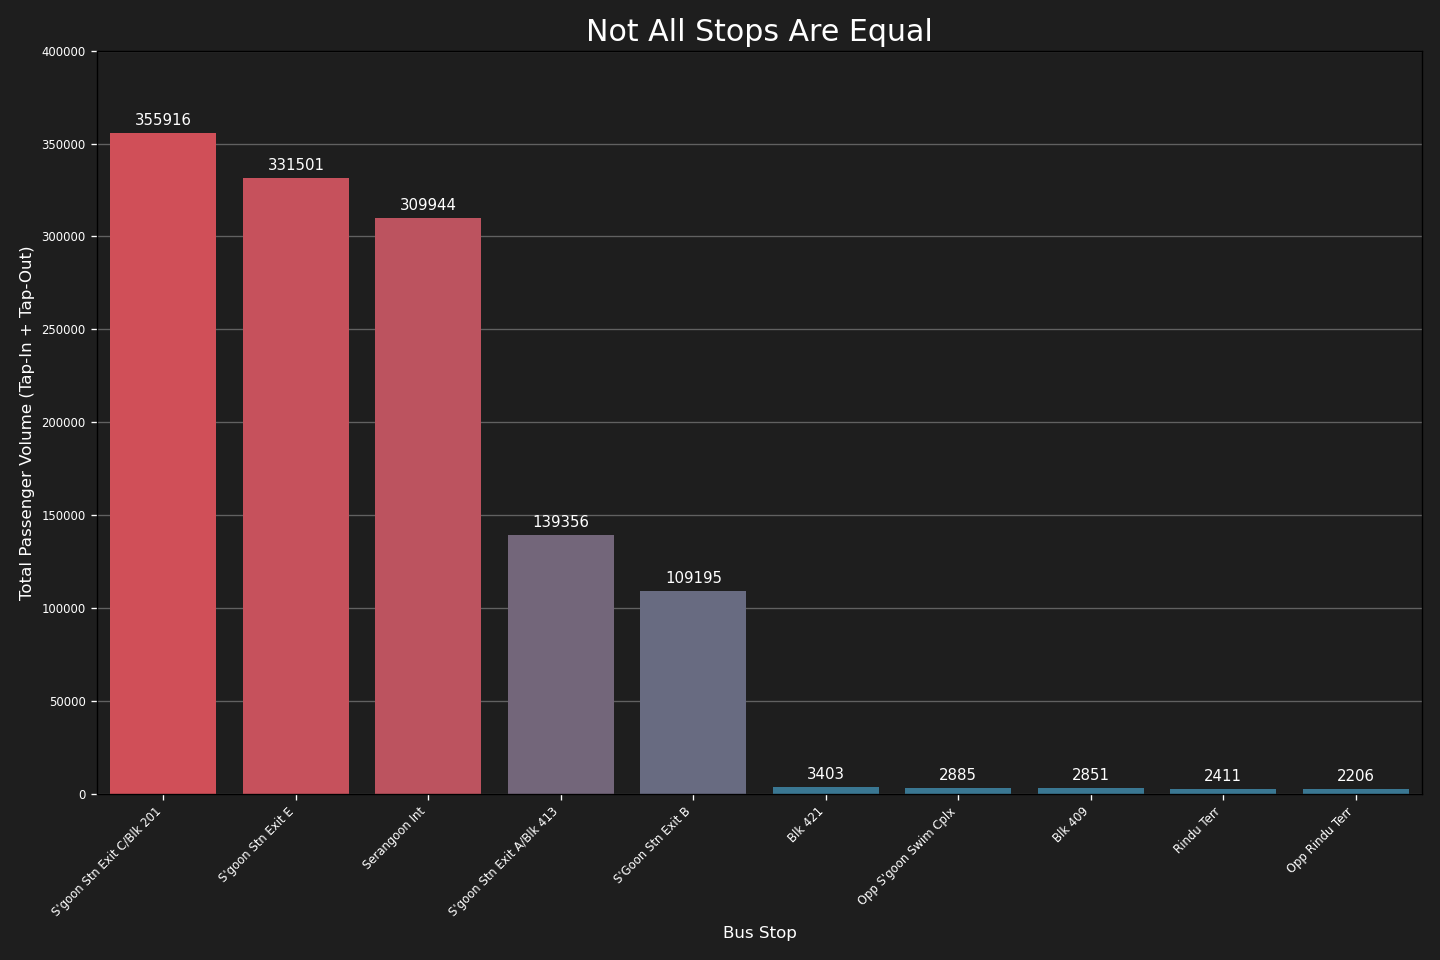

In [33]:
# Plot 1: Top 5 vs Bottom 5 Corridor Bus Stops by Total Passenger Volume 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
from folium.plugins import HeatMap
import base64
from io import BytesIO
from IPython.display import HTML, display

# Filtering desired rows
top5 = stop_volume.head(5)
bottom5 = stop_volume.tail(5)
plot_df = pd.concat([top5, bottom5])

# Colour mapping
norm = mcolors.Normalize(vmin=plot_df['total_volume'].min(), # rescales volume numbers into 0-1 range for cmap reading
                         vmax=plot_df['total_volume'].max())
cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_red", ["#2c7da0", "#e63946"])  # blue (low) to red (high), monotonic
bar_colors = [cmap(norm(v)) for v in plot_df['total_volume']] # unique col p/bar

# Plot dimensions 
fig, ax = plt.subplots(figsize=(12, 8))

# Plot + annotations (annotations depend on the plotted bars existing)
sns.barplot(data=plot_df, 
            x='Description', 
            y='total_volume', 
            hue='Description',
            palette=bar_colors, # unique col p/bar
            legend=False, 
            ax=ax)
for container in ax.containers:
    ax.bar_label(container, 
                 fmt='%.0f', 
                 color='white', 
                 padding=3, 
                 fontsize=9)
# Grid behind plots
ax.grid(axis='y', 
        color='white', 
        alpha=0.3, 
        zorder=0)
ax.set_axisbelow(True)  

# Styling
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')
ax.set_xticks(ax.get_xticks())
ax.set_yticks(ax.get_yticks())
ax.tick_params(axis='both', colors='white', labelsize=7)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Total Passenger Volume (Tap-In + Tap-Out)', color='white')
ax.set_xlabel('Bus Stop', color='white', fontsize=10)
ax.set_title('Not All Stops Are Equal', color='white', fontsize=18)
plt.tight_layout()

# Export to base64 PNG for side-by-side HTML layout
buf = BytesIO()
fig.savefig(buf, format='png', dpi=120)
plt.close(fig)
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode('utf-8')


# Accompanying Folium map: Top 5 vs Bottom 5 bus stops, plus 3 MRT stations
top5_codes = top5['BusStopCode'].tolist()
bottom5_codes = bottom5['BusStopCode'].tolist()
marker_codes = top5_codes + bottom5_codes

map_df = stop_volume[stop_volume['BusStopCode'].isin(marker_codes)].merge(
    corridor_df[['BusStopCode', 'Latitude', 'Longitude']].drop_duplicates('BusStopCode'),
    on='BusStopCode'
)

mrt_stations = {
    'Kovan MRT': (1.3602, 103.8849),
    'Serangoon MRT': (1.3499, 103.8731),
    'Woodleigh MRT': (1.3392, 103.8708),
}

center_lat = map_df['Latitude'].mean()
center_lon = map_df['Longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='CartoDB voyager')

heat_data = [[row['Latitude'], 
              row['Longitude'], 
              row['total_volume']] for _, row in map_df.iterrows()] # weight = glow intensity affected by passenger vol
HeatMap(heat_data, radius=35, blur=15, max_zoom=14).add_to(m) # controlling glow spread

for _, row in map_df.iterrows():
    color = mcolors.to_hex(cmap(norm(row['total_volume'])))
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=10,
        popup=f"{row['Description']}: {int(row['total_volume']):,} pax",
        color=color,
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

for name, (lat, lon) in mrt_stations.items():
    folium.CircleMarker(
        location=[lat, lon],
        radius=10,
        popup=name,
        color='#1d3557',
        fill=True,
        fill_color='#457b9d',
        fill_opacity=0.9
    ).add_to(m)

# Collect all coordinates to fit bounds (bus stops + MRT stations) 
all_coords = [[row['Latitude'], row['Longitude']] for _, row in map_df.iterrows()]
all_coords += [[lat, lon] for lat, lon in mrt_stations.values()]

m.fit_bounds(all_coords)  # set initial view to fit everything

# Recenter button: call Leaflet's fitBounds() on the map's JS object 
recenter_button = f"""
<button onclick="{m.get_name()}.fitBounds({all_coords});"
        style="position:absolute; top:10px; right:10px; z-index:9999;
               padding:6px 12px; background:white; border:1px solid #999;
               border-radius:4px; cursor:pointer; font-size:13px;">
  Recenter
</button>
"""
m.get_root().html.add_child(folium.Element(recenter_button))

map_render = m.get_root().render().replace(chr(34), "&quot;")
map_html = f'<iframe srcdoc="{map_render}" style="width:100%; height:700px; border:none;"></iframe>'

# Configuration for side by side display
combined = f"""
<div style="display: flex; align-items: flex-start; gap: 10px;">
    <div style="flex: 0.65; height: 700px;">
        <img src="data:image/png;base64,{img_b64}" style="height:100%; width:auto; max-width:100%; object-fit:contain;">
    </div>
    <div style="flex: 0.35; height: 700px;">
        {map_html}
    </div>
</div>
"""
display(HTML(combined))

<div class="fig-caption">Figure 1: Tap-in vs tap-out, top 5 stops — Serangoon Station dominates total footfall.</div>

#### 4.1.1 Plot 1 analysis
* Top 5 highest volume stops range between 100,000 to 350,000 taps. 
* Bottom 5 lowest volume stops have extremely scarce daily ridership (Quick math: 109 to 71 passengers on daily average for 31-day May).
* Highest volume stops congregate around rail access point ~ primarily Serangoon station, and interestingly not at the other two stations. 
    * Could also suggest greater residential density around that particular region, given that the full list of bus stops fall within a corridor containing 3 stations.

### 4.2 Plotting inbound and outbound journeys

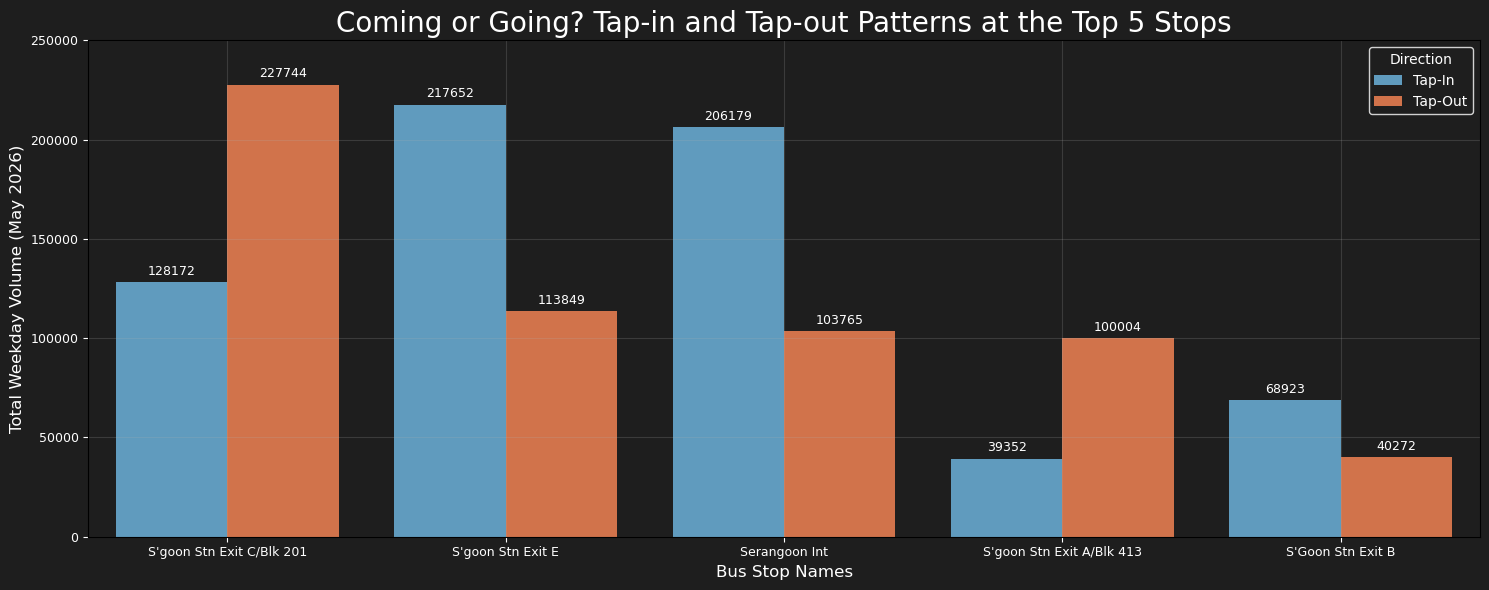

In [30]:
# Plot 2: Tap-In vs Tap-Out for Top 5 NE Corridor Bus Stops by Total Monthly Passenger Volume

# Data prep: Narrowing Top 5 highest-vol stops and converts from Pandas Series into Python list
top5_codes = stop_volume.head(5)['BusStopCode'].tolist()

# Data prep:
direction_df = (
# .isin() filters Top5 BusStopCode's row from corridor_df using True/False
    corridor_df[corridor_df['BusStopCode'].isin(top5_codes)]
# Groupby 2 select columns, displaying tap-in, tap-out data side-by-side
    .groupby(['BusStopCode', 'Description'], as_index=False)[['TOTAL_TAP_IN_VOLUME', 'TOTAL_TAP_OUT_VOLUME']]
# Totalling all taps in/out
    .sum()
# merging the total_volume column with the BusStopCode column
    .merge(stop_volume[['BusStopCode', 'total_volume']], on='BusStopCode')
# Sort by overall size
    .sort_values('total_volume', ascending=False)
)

# .melt() reshapes from "one row p/stop, two separate columns" to "one row p/stop p/direction"
direction_long = direction_df.melt(
    id_vars=['Description'],
    value_vars=['TOTAL_TAP_IN_VOLUME', 'TOTAL_TAP_OUT_VOLUME'],
    var_name='Direction',
    value_name='Volume'
)
direction_long['Direction'] = direction_long['Direction'].map({
    'TOTAL_TAP_IN_VOLUME': 'Tap-In',
    'TOTAL_TAP_OUT_VOLUME': 'Tap-Out'
})

# Colour mapping — same icefire colormap as Plot 1, pulled at two contrasting points
icefire_cmap = sns.color_palette("icefire", as_cmap=True)
palette = [icefire_cmap(0.15), icefire_cmap(0.85)]  # blue end, orange/red end

# Plot dimensions
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

# Plot + annotations
sns.barplot(data=direction_long, x='Description', y='Volume', hue='Direction', palette=palette, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', color='white', padding=3, fontsize=9)
ax.grid(alpha=0.2)
ax.set_xticks(ax.get_xticks())
ax.set_yticks(ax.get_yticks())
ax.tick_params(axis='both', colors='white', labelsize=9)

# Styling: labels + layout
ax.set_xlabel('Bus Stop Names', fontsize=12, color='white')
ax.set_ylabel('Total Weekday Volume (May 2026)', fontsize=12, color='white')
ax.set_title('Coming or Going? Tap-in and Tap-out Patterns at the Top 5 Stops', fontsize=20, color='white')

# Legend styling
legend = ax.legend(title='Direction')
legend.get_frame().set_facecolor('#1e1e1e')
legend.get_frame().set_edgecolor('white')
for text in legend.get_texts():
    text.set_color('white')
legend.get_title().set_color('white')

plt.tight_layout()
plt.show()

<div class="fig-caption">Figure 2: Tap-In vs Tap-Out for Top 5 NE Corridor Bus Stops by Total Monthly Passenger Volume.</div>

#### 4.2.1 Plot 2 analysis

* <b>[Arrival Points]</b> Serangoon Station Exit C/Blk 201, and Serangoon Station Exit A/Blk 413
    * For former, tap-out (227,744) far exceeds tap-in (128,172) indicates strong in-flow. This could be interpreted as a corridor outbound station, and that there are possibly opportunities for multi-modality (i.e. bus-train transfers).
    * Simliar analysis noted for latter.
* <b>[Departure Points]</b> Serangoon Station Exit E, Serangoon Interchange, and Serangoon Station Exit B
    * The reverse is observed, where tap-in exceeds tap-out indicates outflow. This could be interpreted as a corridor inbound station, and that there are possibly opportunities for multi-modality (i.e. train-bus transfers).

### 4.3 Plotting congestion across an average weekday

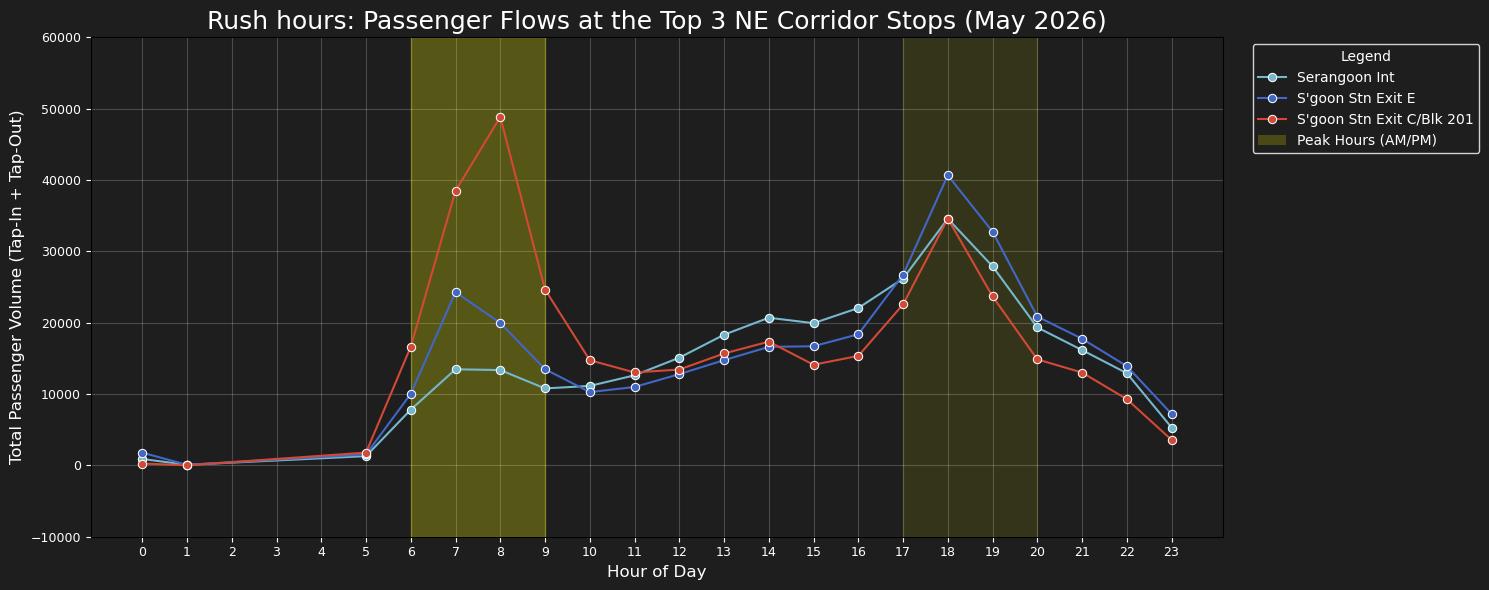

In [31]:
# Plot 3: Passenger Flows Per Hour on an Average Weekday at Top 3 NE Corridor Bus Stops
from matplotlib.patches import Patch # generic matplotlib shape object

# Data prep: Grabbing Top 3 highest-vol stops and converts from Pandas Series into Python list
top3_codes = stop_volume.head(3)['BusStopCode'].tolist()

# Data prep: 
hourly_top3 = (
# .isin() filters Top3 BusStopCode's row from corridor_df using True/False
    corridor_df[corridor_df['BusStopCode'].isin(top3_codes)]
# Groupby 3 select columns, incl. Time P/H for study
    .groupby(['BusStopCode', 'Description', 'TIME_PER_HOUR'], as_index=False)['total_volume']
    .sum()
    .sort_values('TIME_PER_HOUR')
)

# Colour mapping
icefire_cmap = sns.color_palette("icefire", as_cmap=True)
line_colors = [icefire_cmap(0.1),   # light blue 
               icefire_cmap(0.25),  # cool blue
               icefire_cmap(0.8)]   # warm -> highest congestion

# Plot dimensions
fig, ax = plt.subplots(figsize=(15, 6))
# Grey bg for plot
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

# Plot of Top 3 highest-vol bus stops
sns.lineplot(data=hourly_top3, 
             x='TIME_PER_HOUR', 
             y='total_volume', 
             hue='Description', # groups lines by bus stop name
             palette=line_colors, # ensures each grouped line has distinct colour
             marker='o', 
             ax=ax)
# Highlighting the congestion windows
ax.axvspan(6,            # AM peak window
           9, 
           color='yellow', 
           alpha=0.25)   
ax.axvspan(17,           # PM peak window
           20, 
           color='yellow', 
           alpha=0.10)  

# Grid behind plots
ax.grid(alpha=0.2, 
        color='white', 
        zorder=0)
ax.set_axisbelow(True)

# Styling
ax.set_xticks(range(0, 24))
ax.set_yticks(ax.get_yticks())
ax.tick_params(axis='both', 
               colors='white', 
               labelsize=9)
ax.set_xlabel('Hour of Day', 
              color='white', 
              fontsize=12)
ax.set_ylabel('Total Passenger Volume (Tap-In + Tap-Out)', 
              color='white', 
              fontsize=12)
ax.set_title('Rush hours: Passenger Flows at the Top 3 NE Corridor Stops (May 2026)',
             color='white', 
             fontsize=18)

# Legend styling 
peak_patch = Patch(facecolor='yellow', # define shape object's properties fir AM/PM peak
                   alpha=0.2, 
                   label='Peak Hours (AM/PM)')
handles, labels = ax.get_legend_handles_labels() # 3 Line2D objects representing each stop + text labels
handles.append(peak_patch) # adding AM/PM peak to legend
labels.append('Peak Hours (AM/PM)') 
legend = ax.legend(handles=handles, # setting up legend with our defined properties
                   labels=labels, 
                   title='Legend',
                    bbox_to_anchor=(1.02, 1), 
                   loc='upper left')

legend.get_frame().set_facecolor('#1e1e1e') # setting up legend frame 
legend.get_frame().set_edgecolor('white')
for text in legend.get_texts():
    text.set_color('white')
legend.get_title().set_color('white')

plt.tight_layout()
plt.show()

<div class="fig-caption">Figure 3: Passenger Flows Per Hour on an Average Weekday at Top 3 NE Corridor Bus Stops.</div>

#### 4.3.1 Plot 3 analysis
* The morning peak window has more extreme changes in passenger volume compared to the evening peak window
* The three bus stops have quite starkly different passenger volumes in the morning, with Serangoon Station Exit C/Blk 201 having the highest change  
* The three bus stops have a similar rise-fall flow during the evening peak window
* Worth noting that both red & cool blue bus stops are connected to the North East MRT line, and the light blue is connected to a bus interchange.

### 4.4 Plotting distribution of passenger volume across 63 bus stops

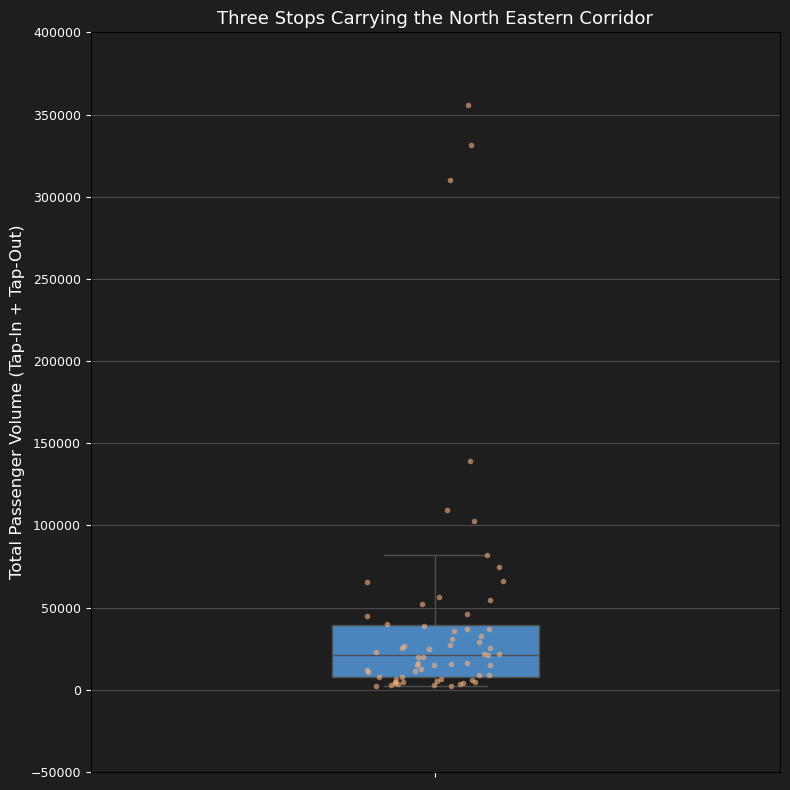

,Description,total_volume
56,S'goon Stn Exit C/Blk 201,355916.0
55,S'goon Stn Exit E,331501.0
52,Serangoon Int,309944.0


In [32]:
# Plot 4: Distribution of Total Weekday Passenger Volume across 63 Corridor Bus Stops

# Colour mapping 
icefire_cmap = sns.color_palette("icefire", 
                                 as_cmap=True)
box_color = icefire_cmap(0.20)    # cool end, for the box itself
point_color = icefire_cmap(0.95)  # warm end, visible against dark bg, distinct from box

# Plot dimensions
fig, ax = plt.subplots(figsize=(8, 8))
# Grey bg for plot
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e') 

# Plot
# Box: IQR + Median
sns.boxplot(y=stop_volume['total_volume'], 
            color=box_color, 
            width=0.3, 
            ax=ax, 
            showfliers=False)
# 63 bus stops 
sns.stripplot(y=stop_volume['total_volume'], 
              color=point_color, 
              alpha=0.6, 
              size=4, 
              jitter=True, 
              ax=ax)
# Grid behind plots
ax.grid(axis='y', 
        alpha=0.2, 
        color='white', 
        zorder=0)
ax.set_axisbelow(True)

# Styling
ax.set_yticks(ax.get_yticks())
ax.tick_params(axis='both', 
               colors='white', 
               labelsize=9)
ax.set_ylabel('Total Passenger Volume (Tap-In + Tap-Out)', 
              color='white', 
              fontsize=12)
ax.set_title('Three Stops Carrying the North Eastern Corridor',
             color='white', 
             fontsize=13)

plt.tight_layout()
plt.show()

# Identifying 3 outliers
stop_volume.nlargest(3, 'total_volume')[['Description', 'total_volume']]

<div class="fig-caption">Figure 4: Distribution of Total Weekday Passenger Volume across 63 Corridor Bus Stops.</div>

#### 4.4.1 Plot 4 analysis
* Three stops carry disproportionately high volume relative to the rest of the North East Corridor

<a id="conclusion"></a>
## 5. Conclusion

<b>Answering the RQ</b>
> Passenger load concentrates sharply around Serangoon's MRT station exits, with comparatively little signal of bus-rail integration at Kovan or Woodleigh MRT stations
* Load is highly uneven across the north eastern corridor, particularly at the bus stops surrounding Serangoon
    * evidenced by Plot 1 (volume concentration + Folium map), Plot 4 (distribution) 
* While included in the dataset, bus stops surrounding Kovan and Woodleigh didn't make it to the Top or Bottom.
* For the bottom stops that still fall within Serangoon's catchment with minimal traffic
    * proximity to Serangoon alone doesn't predict volume: these stops are 240 – 840m from the MRT, while the top 5 are 0m from station exits.
    * this suggests <b> volume concentration is driven by direct rail-transfer function </b>, not just geographic nearness to the station.
* Plot 2 and 3 enable deeper forensic understanding of congestion in that we are able to determine direction (inbound/outbound imbalance for former), and time window peaks. Both shed light into where bus-rail systems require greater integration for smoother transfers (i.e. increased turnover, lower waiting times, more ground staff deployments...etc).

##### So what?
* Serangoon's bus passenger volume data provides insight into what bus-rail integration needs are, and where gaps might need to be plugged.
* Comparisons with other equally loaded corridors is likely to lead to greater learning, and clearer evaluation of LTMP 2040's policy effectiveness.

##### Limitations of study
* These analyses were based on a single month of data collection in May 2026 for <b> weekdays </b> only.
* Only looked at bus passenger volume, and examining rail passenger volume in tandem would enable more thorough analysis.

<a id="ref"></a>
## 6. References & Acknowledgements

I would like to thank Dr Chaitanya Rao, my course instructor, as well as Rachel Anastasi-Marais, our course teaching assistant, for their invaluable help and coaching throughout the course so far. None of these developing data analytical skills would have been possible within a condensed timeframe without their encouragement and skills building tutoring. 

Many thanks to the LTA Datamall team for their help in solving a silly API key-access blip so I could more readily access the rich store of data made ready to the public for such analytical projects. I am also grateful for access to URA's [OneMap](https://www.onemap.gov.sg/apidocs/authentication), whose interactive features made intuitively figuring out a geographical boundary for EDA a lot easier for manipulating with Pandas's coding logic. 

###### Disclaimer: 
The observations and take-aways expressed in this notebook are for the purposes of personal data exploration and analysis.